[![preview notebook](https://img.shields.io/static/v1?label=render%20on&logo=github&color=87ce3e&message=GitHub)](https://github.com/open-atmos/PySDM/blob/main/examples/PySDM_examples/Zaba_et_al/isotopic_ratios.ipynb)
[![launch on mybinder.org](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/open-atmos/PySDM.git/main?urlpath=lab/tree/examples/PySDM_examples/Zaba_et_al/isotopic_ratios.ipynb)
[![launch on Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/open-atmos/PySDM/blob/main/examples/PySDM_examples/Zaba_et_al/isotopic_ratios.ipynb)

# Isotopic ratios


In [1]:
import os, sys
os.environ['NUMBA_THREADING_LAYER'] = 'workqueue'  # PySDM & PyMPDATA don't work with TBB; OpenMP has extra dependencies on macOS
if 'google.colab' in sys.modules:
    !pip --quiet install open-atmos-jupyter-utils
    from open_atmos_jupyter_utils import pip_install_on_colab
    pip_install_on_colab('PySDM-examples', 'PySDM')

In [45]:
import numpy as np
from itertools import cycle
from matplotlib import pyplot
from collections import namedtuple
from scipy.interpolate import RegularGridInterpolator
from matplotlib.ticker import FuncFormatter
from open_atmos_jupyter_utils import show_plot

from PySDM import Formulae
from PySDM.dynamics.isotopic_fractionation import HEAVY_ISOTOPES
from PySDM.physics.constants import si, PER_MILLE, in_unit, PER_CENT
from examples.PySDM_examples.Zaba_et_al.simulation import Simulation

In [46]:
IsotopeContext = namedtuple("IsotopeContext", ["iso", "T"])
Parameters = namedtuple(
    "params", [
        "D_ratio",
        "f_ratio",
        "alpha_w",
        "alpha_i",
        "Fk",
        "Fd",
        "b",
        "vsmow",
    ]
)

Commons = namedtuple("Commons", ["f", "c", "iso", "T", "params"])

class CommonsFactory:
    """Compute and assemble common isotope quantities."""
    def __init__(self, formulae):
        self._f = formulae
        self._const = formulae.constants

    def build(self, ctx: IsotopeContext):
        """build factory"""
        return Commons(
            f=self._f,
            c=self._const,
            iso=ctx.iso,
            T=ctx.T,
            params=self._build_params(ctx),
        )

    def _build_params(self, ctx):
        vsmow = getattr(self._const, f"VSMOW_R_{ctx.iso}")
        diff_fun = getattr(
            self._f.isotope_diffusivity_ratios,
            f"ratio_{ctx.iso}_heavy_to_light",
        )
        D_ratio = diff_fun(ctx.T) 
        ventilation_ratio = (
            self._f.isotope_ventilation_ratio.ratio_heavy_to_light(
                ventilation_coefficient=np.nan,
                diffusivity_ratio_heavy_to_light=D_ratio,
            )
        )
        alpha_l = getattr(
            self._f.isotope_equilibrium_fractionation_factors,
            f'alpha_l_{ctx.iso}',
        )
        alpha_i = getattr(
            self._f.isotope_equilibrium_fractionation_factors,
            f'alpha_i_{ctx.iso}',
        )
        pvs = self._f.saturation_vapour_pressure.pvs_water(ctx.T)
        Fk = self._f.drop_growth.Fk(
            T=ctx.T,
            K=self._const.K0,
            lv=self._f.latent_heat_vapourisation.lv(ctx.T),
        )
        Fd = self._f.drop_growth.Fd(
            pvs=pvs,
            T=ctx.T,
            D=self._const.D0,
        )
        rho_s = pvs / self._const.Rv / ctx.T
        return Parameters(
            D_ratio=D_ratio,
            f_ratio=ventilation_ratio,
            alpha_w=alpha_l(ctx.T),
            alpha_i=alpha_i(ctx.T),
            Fk=Fk,
            Fd=Fd,
            b=rho_s * Fk / self._const.rho_w * self._const.D0,
            vsmow=vsmow,
        )
    
C2K = Formulae().trivia.C2K

In [47]:
def calculate_delta_change(
    *,
    relative_humidity,
    molecular_R_liq,
    multiplicity,
    commons,
    volume,
    radius,
):  # pylint: disable=too-many-arguments
    """perform multiple calculations for different grid nodes
    result: matrix of relative mass change of the heavy isotope
    in liquid and vapour phase"""
    dR_dt_vap = np.zeros((len(relative_humidity), len(molecular_R_liq)))
    dR_dt_liq = np.zeros_like(dR_dt_vap)
    Bolin_number = np.zeros_like(dR_dt_vap)
    
    attributes = ATTRIBUTES.copy()
    attributes["multiplicity"] = multiplicity
    attributes['signed water mass'] = commons.c.rho_w * 4 / 3 * np.pi * radius**3
    for i, rh in enumerate(relative_humidity):
        c = (
            4 * np.pi * commons.c.rho_w
            / (commons.params.Fk + commons.params.Fd)
        )
        for j, m_R_liq in enumerate(molecular_R_liq):
            particulator, init_conc_vap = Simulation.make_particulator(
                ff=commons.f,
                molecular_isotopic_ratio=m_R_liq,
                initial_R_vap=ISO_RATIO_V,
                attributes=attributes,
                n_sd=1,
                relative_humidity=rh,
                dv=volume,
                T=commons.T,
                dt=666 * si.s,
                isotope=commons.iso,
            )
            dR_dt_vap[i,j], dR_dt_liq[i,j], Bolin_number[i,j] = Simulation.do_one_step(
                ff=commons.f,
                particulator=particulator,
                dm_dt_per_droplet=c * radius * (rh - 1),
                init_m_R_liq=m_R_liq,
                initial_conc_vap=init_conc_vap,
                isotope=commons.iso,
            )
    return dR_dt_vap/commons.params.vsmow, dR_dt_liq/commons.params.vsmow, Bolin_number

In [48]:
class Paper:
    """Configuration reproducing the paper setup."""
    formulae = Formulae(
        isotope_equilibrium_fractionation_factors="VanHook1968",
        isotope_kinetic_fractionation_factors="JouzelAndMerlivat1984",
        isotope_relaxation_timescale="ZabaEtAl",
        isotope_diffusivity_ratios="HellmannAndHarvey2020",
        isotope_ratio_evolution="ZabaEtAl", 
        isotope_ventilation_ratio="Neglect",
        isotope_meteoric_water_line="BarkanAndLuz2007+Dansgaard1964",
        drop_growth="Mason1971",
    )
    isotope = "2H"
    delta_v = -200 * PER_MILLE
    temperature = C2K(10.0) * si.K
    xlim = (0.8, 1.05)
    rh_lim = (0.0, 1.05)
    rh_unit = PER_CENT

ATTRIBUTES = {
    "dry volume": np.nan,
    "kappa times dry volume": np.nan,
    **{f"moles_{isotope}": 0.0 * si.mole for isotope in HEAVY_ISOTOPES},
    "multiplicity": 1 * np.ones(1),
}

cmn = CommonsFactory(Paper.formulae).build(
    IsotopeContext(iso=Paper.isotope, T=Paper.temperature)
)
ISO_RATIO_V = cmn.f.trivia.isotopic_delta_2_ratio(Paper.delta_v, cmn.params.vsmow)

In [102]:
grid = (32, 32)
setup = {}
r_pristine = 0.5 * si.mm
setup["pristine"] = {"nd": (nd_pristine:=10), "r": r_pristine}
setup["polluted_same_radii"] = {"nd": (nd_polluted:=30), "r": r_pristine}
setup["polluted_same_total_mass"] = {"nd": nd_polluted, "r": nd_pristine * r_pristine / nd_polluted}

d_delta_dt = {}
Bo = {}

for aerosol in setup.keys():
    d_delta_dt[aerosol] = {}
    d_delta_dt_vap, d_delta_dt_liq, Bolin_number = calculate_delta_change(
        relative_humidity=np.linspace(*Paper.rh_lim, grid[1]),
        molecular_R_liq=np.linspace(*Paper.xlim, grid[0]) * cmn.params.vsmow,
        multiplicity=setup[aerosol]["nd"] * np.ones(1),
        commons=cmn,
        volume=np.ones(1) * si.dm**3,
        radius=setup[aerosol]["r"],
    )
    d_delta_dt[aerosol]["liquid"] = d_delta_dt_liq
    d_delta_dt[aerosol]["vapour"] = d_delta_dt_vap
    Bo[aerosol] = Bolin_number

# G&A vs one step PySDM

In [103]:
def xy_masked(x, y, xlim, ylim):
    mask = (
        (x >= xlim[0]) & (x <= xlim[1]) &
        (y >= ylim[0]) & (y <= ylim[1])
    )
    return x[mask], y[mask], mask

def z_eps_mask(z, eps):
    return {
        'z < -': np.where(z < -eps, z, np.nan),
        '|z| <': np.where(np.abs(z) < eps, z, np.nan),
        'z >': np.where(z > eps, z, np.nan),
    }
eps_colors = {
    'z < -': 'darkblue',
    '|z| <': 'pink',
    'z >': 'gold'
}    

In [104]:
def no_fractionation_saturation(x, iso_ratio_v, cmn, phase, if_alpha_ice=False):
    iso_ratio_r = x * cmn.params.vsmow
    return cmn.f.isotope_ratio_evolution.saturation_for_zero_dR_condition(
        iso_ratio_x=iso_ratio_v if phase=='vapour' else iso_ratio_r,
        diff_rat_heavy_to_light=(
            cmn.params.f_ratio * cmn.params.D_ratio
        ),
        alpha=cmn.params.alpha_i if (phase=='ice' or if_alpha_ice) else cmn.params.alpha_w,
        iso_ratio_r=iso_ratio_r,
        iso_ratio_v=iso_ratio_v,
        Fd=cmn.params.Fd,
        Fk=cmn.params.Fk,
    )

In [105]:
phases = ("liquid", "vapour")

X = np.linspace(*Paper.xlim, grid[0])
Y = np.linspace(*Paper.rh_lim, grid[1])
XX, YY = np.meshgrid(X, Y)
X_eq = ISO_RATIO_V * cmn.params.alpha_w /cmn.params.vsmow
Y_eq = 1
in_cloud = Y >= Y_eq
cloud_XX, cloud_YY = np.meshgrid(X, Y[in_cloud])

In [141]:
def plot_case(polluted_case):
    fig, axs = pyplot.subplots(
        1, 2,
        figsize=(10, 6),
        subplot_kw={'projection': '3d'},
        constrained_layout=True,
    )
    fig.suptitle(
        f"Case: {polluted_case}\n"
        f"Pristine case: $n={setup["pristine"]["nd"]:.2g}, r={in_unit(setup["pristine"]["r"], si.mm):.2g}$ [mm]\n"
        f"Polluted case: $n={setup[polluted_case]["nd"]:.2g}, r={in_unit(setup[polluted_case]["r"], si.mm):.2g}$ [mm]"
    )
    eps=1e-5
    for i, ax in enumerate(axs.flat):
        ax.set(
            xlim=Paper.xlim,
            xlabel=r"$\delta_\text{liq} + 1 = \frac{R_\text{liq}}{R_\text{VSMOW}}$ [1]",
            ylim=(.4, 1.05),
            yticks=(.5, .75, 1., 1.05),
        )
        ax.yaxis.set(
            major_formatter=FuncFormatter(lambda x, _: f"{in_unit(x, PER_CENT):.0f}"),
            label_text='S=RH [%]'
        )
        ax.zaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{in_unit(x, PER_MILLE):.2g}"))
        ax.text2D(
            1, 0.83,
            rf"$z \left[\frac{{‰}}{{s}}\right]$",
            transform=ax.transAxes,
        )
        ax.view_init(elev=45, azim=-65)
        ax.tick_params(axis='y', pad=-2)
        ax.tick_params(axis='z', pad=8)
    
    for ax, phase in zip(axs, phases):
        Zp = d_delta_dt[polluted_case][phase]
        ax.plot_surface(XX, YY, Zp, color="grey", alpha=0.07, zorder=2.05, axlim_clip=True, edgecolor=None)
        ax.plot_wireframe(XX, YY, Zp, color="k", alpha=0.3, zorder=2.05, linewidth=.5, axlim_clip=True)
        
        Z = d_delta_dt["pristine"][phase]    
        interp = RegularGridInterpolator((Y, X), Z)
    
        for label, z in z_eps_mask(Z, eps).items():
            ax.plot_wireframe(
                XX, YY, z,
                label=f"${label}\epsilon$",
                alpha=0.65,
                color=eps_colors[label],
                zorder=2.05,
                axlim_clip=True,
            )
        x, y = X, np.full_like(X, Y_eq)
        ax.plot(x, y, interp(np.c_[y, x]), c='maroon', lw=2, zorder=3)
        ax.text(X[0], Y[-1], 0, 'phase equil.\n  RH=100%', c='maroon')
        
        z_point = interp((Y_eq, X_eq))
        ax.scatter(X_eq, Y_eq, z_point, c='r', s=15, zorder=1000)
        ax.text(X_eq, Y_eq, z_point, '$\\bf\\longleftarrow$', 'y', c='r')
        ax.text(1.01*X_eq, 1.1*Y_eq, z_point, r'$R_\text{liq} = \alpha(T)\cdot R_{\text{vap}}$', c='r')
    
        
        for p, ls in zip(phases, ('-', ':')):
            x, y, mask = xy_masked(
                x=(x:= np.linspace(X_eq, 1.05, 2000)),
                y=no_fractionation_saturation(x, ISO_RATIO_V, cmn, p),
                xlim=ax.get_xlim(),
                ylim=ax.get_ylim(),
            )
            plt_line = ax.plot(x, y, interp(np.c_[y, x]), c='k', lw=2.5, ls=ls, zorder=3, axlim_clip=True)[0]
            tmp_x, tmp_y, tmp_z = plt_line.get_data_3d()
            ax.text(tmp_x[-1], .8*tmp_y[-1], tmp_z[-1], '$\\bf\\longrightarrow$', 'y', c='k')
            ax.text(tmp_x[-1], .7*tmp_y[-1], tmp_z[-1], rf"$S_\text{{{p[:3]}}}^\text{{eq}}$", c='k')
        
        elaborate = "" if phase[0] == 'v' else r"$=\frac{\delta_\text{liq}+1}{\tau_\text{total}}\left(\frac{1}{\text{Bo}}-1\right)$"
        ax.set_title(rf"$\bf{{({ {'l':'A', 'v':'B'}[phase[0]] })}}$ {phase}:  ${{d\delta_\text{{{phase[:3]}}}}}/{{dt}}$ " + elaborate)
        ax.legend(loc="upper left", handlelength=1.2)
    
    show_plot(f"comparison_{polluted_case}")

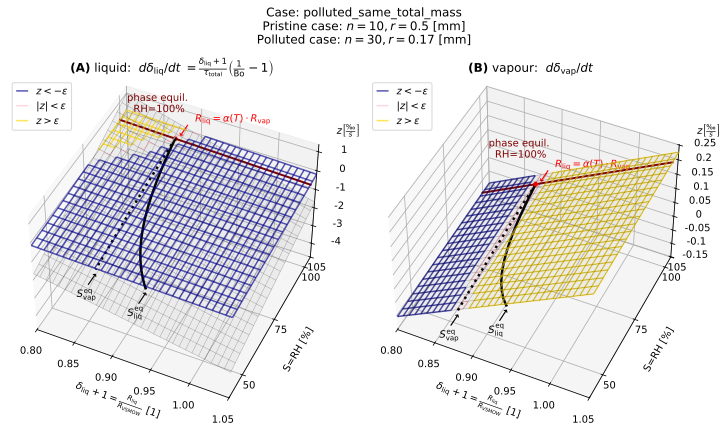

In [142]:
plot_case(polluted_case="polluted_same_total_mass")

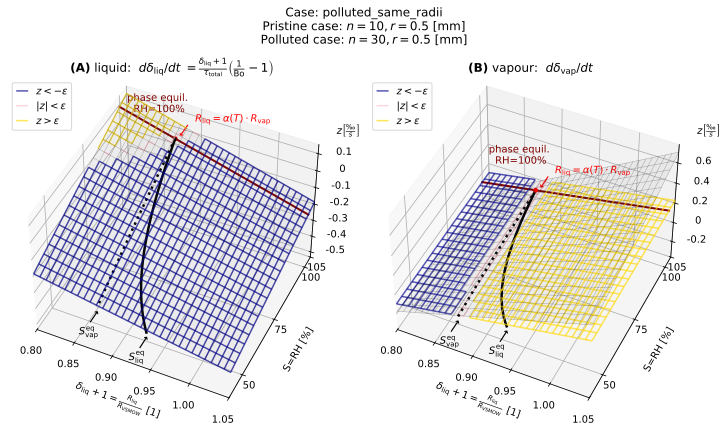

In [143]:
plot_case(polluted_case="polluted_same_radii")

# Possible unit test for no fractionation saturation 

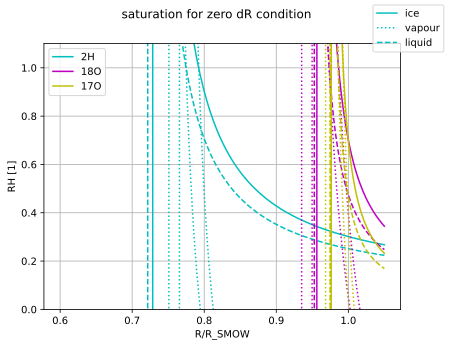

In [10]:
fig, ax = pyplot.subplots()

iso_mwl = cmn.f.isotope_meteoric_water_line
isotopes = "2H", "18O", "17O"
delta_2H = -300 * PER_MILLE
delta_18O = iso_mwl.d18O_of_d2H(delta_2H)
delta_17O = iso_mwl.d17O_of_d18O(delta_18O)
deltas = {
    '2H': delta_2H,
    '18O': delta_18O, 
    '17O': delta_17O,
}

colors = cycle(['c', 'm', 'y'])
ls = cycle(['-', '--'])

phases = 'ice', 'liquid'

for idx_iso, iso in enumerate(isotopes):
    cmn = CommonsFactory(Paper.formulae).build(IsotopeContext(iso=iso, T=C2K(0.01)))
    pvs_water = cmn.f.saturation_vapour_pressure.pvs_water(cmn.T)
    pvs_ice = cmn.f.saturation_vapour_pressure.pvs_ice(cmn.T)

    iso_ratio_v = cmn.f.trivia.isotopic_delta_2_ratio(deltas[iso], cmn.params.vsmow)
    color = next(colors)
    for p in phases:
        alpha = cmn.params.alpha_w if p[0] == 'l' else cmn.params.alpha_i
        X_eq = iso_ratio_v * alpha / cmn.params.vsmow
        x = np.linspace(0.6, 1.05, 200)
        line_v = no_fractionation_saturation(x, iso_ratio_v, cmn, 'vapour')
        line_w_or_i = no_fractionation_saturation(x, iso_ratio_v, cmn, p)
        if p == 'ice':
            line_w_or_i *= pvs_ice / pvs_water
            line_v = no_fractionation_saturation(x, iso_ratio_v, cmn, 'vapour', if_alpha_ice=True)
        ax.plot(x, line_w_or_i, c=color, ls=next(ls), label=[iso if p[0]=='i' else ''])
        ax.plot(x, line_v, c=color, ls=':')
ax.set_ylim(0, 1.1)

ax.grid()
ax.legend()
ax.set_xlabel('R/R_SMOW')
ax.set_ylabel('RH [1]')
fig.suptitle('saturation for zero dR condition')
fig.legend(['ice', 'vapour', 'liquid'])
show_plot('fig2')